In [3]:
import os, random, numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

SEED = 42
tf.random.set_seed(SEED)
np.random.seed(SEED)
random.seed(SEED)

print("TF:", tf.__version__)
print("GPUs:", tf.config.list_physical_devices("GPU"))

# Optional (prevents TF from grabbing all VRAM at once)
gpus = tf.config.list_physical_devices("GPU")
if gpus:
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
        print("✅ Memory growth enabled")
    except Exception as e:
        print("Could not set memory growth:", e)


TF: 2.20.0
GPUs: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
✅ Memory growth enabled


In [4]:
import tensorflow as tf
print("GPUs:", tf.config.list_physical_devices("GPU"))
print("Device:", tf.test.gpu_device_name())


GPUs: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
Device: /device:GPU:0


I0000 00:00:1767620884.108935  294099 gpu_device.cc:2020] Created device /device:GPU:0 with 5012 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 3050, pci bus id: 0000:01:00.0, compute capability: 8.6


In [5]:
DATA_DIR = "/media/nosrati/925801bb-fbc8-43cf-abaa-72c55c9e5dc6/projects/ai_learning/ml/Ml_projects/car brand/dataset/iran-used-cars-dataset"
SELECTED_CLASSES = ["Peugeot-206", "Pride-131"]  # change to any 2

IMG_SIZE = 224
BATCH_SIZE = 32


In [8]:
import os
print(os.listdir(os.path.join(DATA_DIR, "split")))


['val', 'train', 'test']


In [9]:
import os
import tensorflow as tf

SEED = 42
SPLIT_DIR = os.path.join(DATA_DIR, "split")

train_dir = os.path.join(SPLIT_DIR, "train")
dev_dir   = os.path.join(SPLIT_DIR, "val")   # dev = validation
test_dir  = os.path.join(SPLIT_DIR, "test")

train_ds = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    class_names=SELECTED_CLASSES,
    seed=SEED,
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    label_mode="binary",
    shuffle=True,
)

dev_ds = tf.keras.utils.image_dataset_from_directory(
    dev_dir,
    class_names=SELECTED_CLASSES,
    seed=SEED,
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    label_mode="binary",
    shuffle=False,
)

test_ds = tf.keras.utils.image_dataset_from_directory(
    test_dir,
    class_names=SELECTED_CLASSES,
    seed=SEED,
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    label_mode="binary",
    shuffle=False,
)

print("Class order (0/1):", train_ds.class_names)


Found 1074 files belonging to 2 classes.
Found 230 files belonging to 2 classes.
Found 232 files belonging to 2 classes.
Class order (0/1): ['Peugeot-206', 'Pride-131']


2026-01-05 17:25:38.707964: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


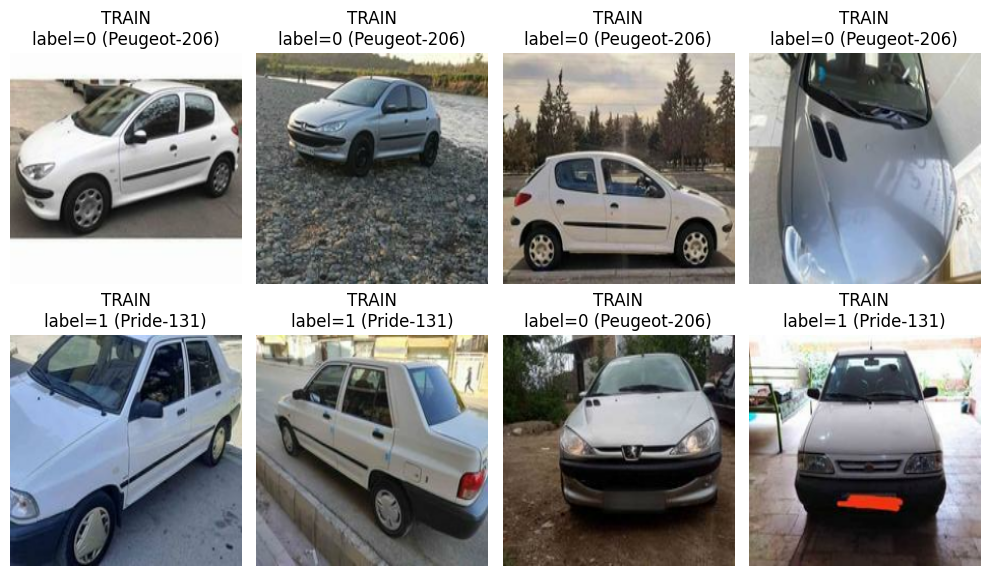

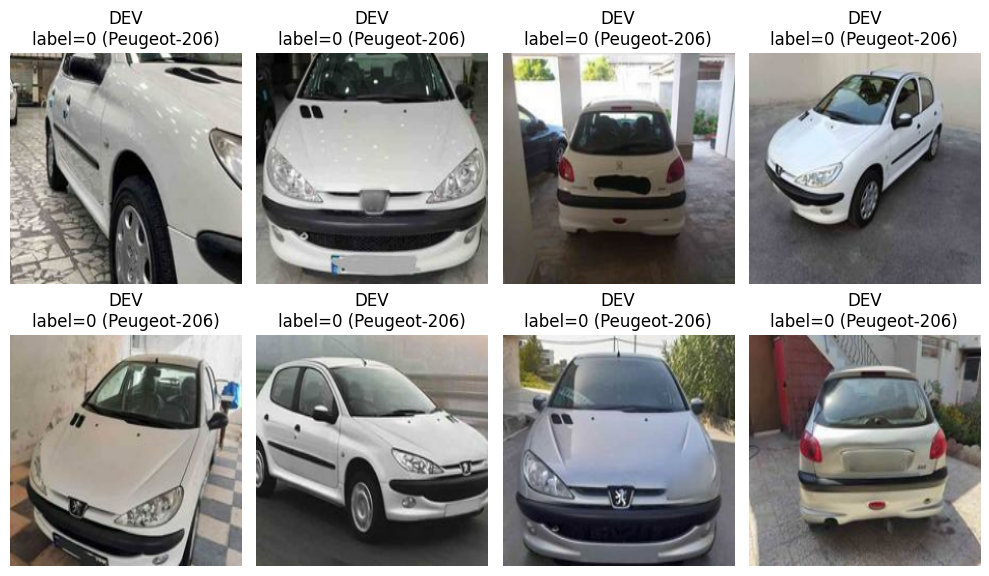

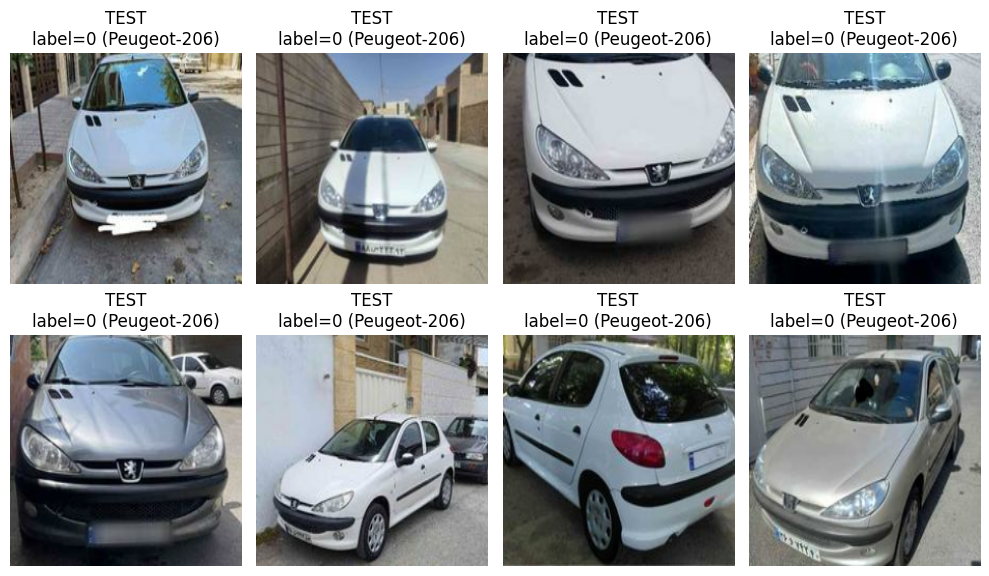

In [12]:
import matplotlib.pyplot as plt

def show_batch(ds, title):
    plt.figure(figsize=(10, 6))
    for images, labels in ds.take(1):
        for i in range(8):
            ax = plt.subplot(2, 4, i+1)
            plt.imshow(images[i].numpy().astype("uint8"))
            # labels have shape (batch, 1); extract a Python scalar with .item()
            y = int(labels[i].numpy().item())
            plt.title(f"{title}\nlabel={y} ({train_ds.class_names[y]})")
            plt.axis("off")
    plt.tight_layout()
    plt.show()

show_batch(train_ds, "TRAIN")
show_batch(dev_ds,   "DEV")
show_batch(test_ds,  "TEST")


In [13]:
import numpy as np

def count_labels(ds):
    c0, c1 = 0, 0
    for _, labels in ds:
        labels = labels.numpy().astype(int).ravel()
        c0 += np.sum(labels == 0)
        c1 += np.sum(labels == 1)
    return c0, c1

print("Train counts:", count_labels(train_ds))
print("Dev counts:  ", count_labels(dev_ds))
print("Test counts: ", count_labels(test_ds))


Train counts: (np.int64(550), np.int64(524))
Dev counts:   (np.int64(118), np.int64(112))
Test counts:  (np.int64(119), np.int64(113))


2026-01-05 17:25:51.304829: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


In [ ]:
import tensorflow as tf

aug = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.05),
    tf.keras.layers.RandomZoom(0.10),
    tf.keras.layers.RandomContrast(0.10),
])

def build_cnn(img_size=224, base_filters=32, dropout=0.3):
    inputs = tf.keras.Input(shape=(img_size, img_size, 3))
    x = aug(inputs)
    x = tf.keras.layers.Rescaling(1./255)(x)

    # Block 1
    x = tf.keras.layers.Conv2D(base_filters, 3, padding="same")(x)
    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.ReLU()(x)
    x = tf.keras.layers.MaxPooling2D()(x)

    # Block 2
    x = tf.keras.layers.Conv2D(base_filters*2, 3, padding="same")(x)
    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.ReLU()(x)
    x = tf.keras.layers.MaxPooling2D()(x)

    # Block 3
    x = tf.keras.layers.Conv2D(base_filters*4, 3, padding="same")(x)
    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.ReLU()(x)
    x = tf.keras.layers.MaxPooling2D()(x)

    x = tf.keras.layers.GlobalAveragePooling2D()(x)
    x = tf.keras.layers.Dropout(dropout)(x)

    outputs = tf.keras.layers.Dense(1, activation="sigmoid")(x)
    return tf.keras.Model(inputs, outputs)

model = build_cnn(img_size=IMG_SIZE, base_filters=32, dropout=0.3)
model.summary()


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential (Sequential)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling (Rescaling)           │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu (ReLU)                    │ (None, 224, 224, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_1 (ReLU)                  │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_2 (ReLU)                  │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 94,273 (368.25 KB)

 Trainable params: 93,825 (366.50 KB)

 Non-trainable params: 448 (1.75 KB)

In [15]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss="binary_crossentropy",
    metrics=["accuracy", tf.keras.metrics.AUC(name="auc")]
)

callbacks = [
    tf.keras.callbacks.EarlyStopping(patience=5, restore_best_weights=True),
    tf.keras.callbacks.ReduceLROnPlateau(patience=2, factor=0.3),
]

history = model.fit(
    train_ds,
    validation_data=dev_ds,
    epochs=20,
    callbacks=callbacks
)


Epoch 1/20


2026-01-05 17:27:01.258219: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:473] Loaded cuDNN version 91701


34/34 ━━━━━━━━━━━━━━━━━━━━ 11s 202ms/step - accuracy: 0.5596 - auc: 0.5779 - loss: 0.7208 - val_accuracy: 0.4870 - val_auc: 0.4077 - val_loss: 0.7453 - learning_rate: 0.0010
Epoch 2/20
34/34 ━━━━━━━━━━━━━━━━━━━━ 5s 143ms/step - accuracy: 0.5549 - auc: 0.6079 - loss: 0.6862 - val_accuracy: 0.4870 - val_auc: 0.4193 - val_loss: 0.7540 - learning_rate: 0.0010
Epoch 3/20
34/34 ━━━━━━━━━━━━━━━━━━━━ 5s 142ms/step - accuracy: 0.5931 - auc: 0.6422 - loss: 0.6749 - val_accuracy: 0.4870 - val_auc: 0.4650 - val_loss: 0.6968 - learning_rate: 0.0010
Epoch 4/20
34/34 ━━━━━━━━━━━━━━━━━━━━ 5s 138ms/step - accuracy: 0.6015 - auc: 0.6557 - loss: 0.6640 - val_accuracy: 0.4870 - val_auc: 0.4598 - val_loss: 0.7399 - learning_rate: 0.0010
Epoch 5/20
34/34 ━━━━━━━━━━━━━━━━━━━━ 5s 137ms/step - accuracy: 0.6425 - auc: 0.6932 - loss: 0.6377 - val_accuracy: 0.4913 - val_auc: 0.4890 - val_loss: 0.7108 - learning_rate: 0.0010
Epoch 6/20
34/34 ━━━━━━━━━━━━━━━━━━━━ 5s 140ms/step - accuracy: 0.6527 - auc: 0.7122 - los

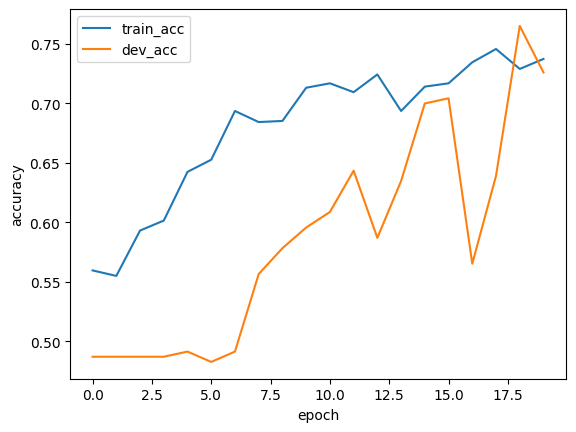

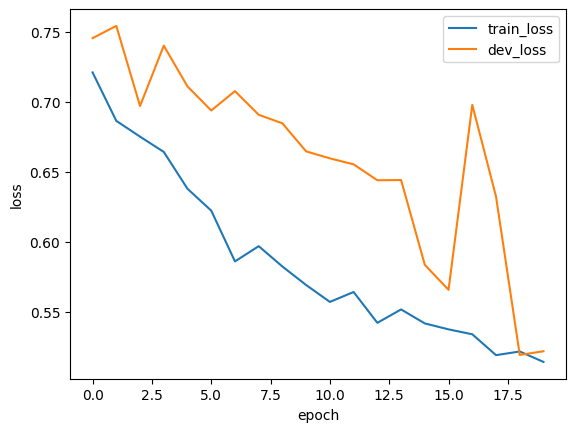

In [16]:
import matplotlib.pyplot as plt

plt.figure()
plt.plot(history.history["accuracy"], label="train_acc")
plt.plot(history.history["val_accuracy"], label="dev_acc")
plt.legend(); plt.xlabel("epoch"); plt.ylabel("accuracy"); plt.show()

plt.figure()
plt.plot(history.history["loss"], label="train_loss")
plt.plot(history.history["val_loss"], label="dev_loss")
plt.legend(); plt.xlabel("epoch"); plt.ylabel("loss"); plt.show()


In [17]:
test_metrics = model.evaluate(test_ds, verbose=0)
print(dict(zip(model.metrics_names, test_metrics)))


{'loss': 0.5162025690078735, 'compile_metrics': 0.7586206793785095}


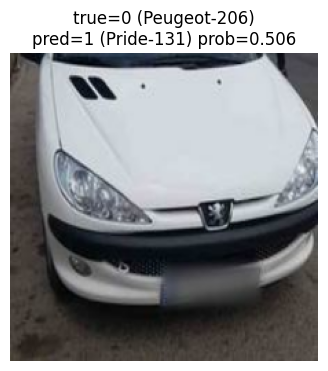

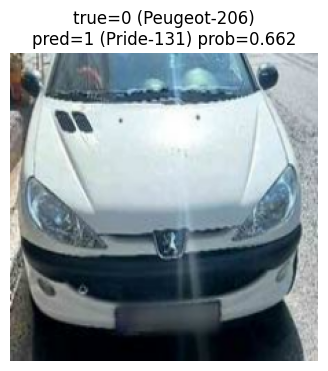

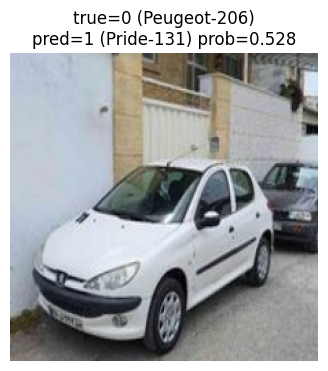

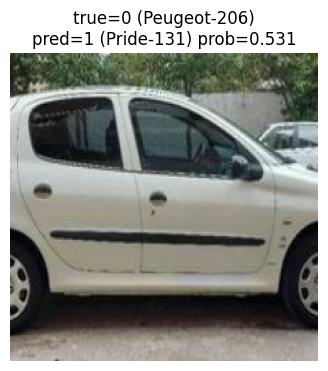

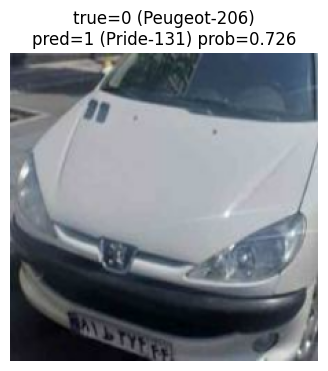

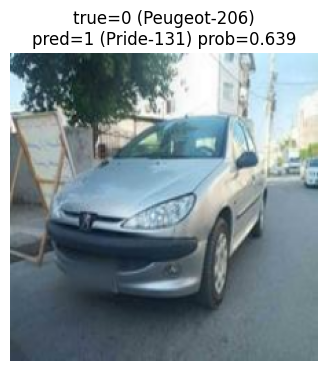

In [19]:
import numpy as np
import matplotlib.pyplot as plt

def show_mistakes(ds, n=8):
    shown = 0
    for images, labels in ds:
        probs = model.predict(images, verbose=0).squeeze()
        preds = (probs >= 0.5).astype(int)
        true  = labels.numpy().astype(int).squeeze()

        wrong = np.where(preds != true)[0]
        for i in wrong:
            plt.figure(figsize=(4,4))
            plt.imshow(images[i].numpy().astype("uint8"))
            plt.title(
                f"true={true[i]} ({train_ds.class_names[true[i]]})\n"
                f"pred={preds[i]} ({train_ds.class_names[preds[i]]}) prob={probs[i]:.3f}"
            )
            plt.axis("off")
            plt.show()
            shown += 1
            if shown >= n:
                return

show_mistakes(test_ds, n=6)
